In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
df = pd.read_csv("anime.csv")
print(df.shape)
print(df.info())
df.head()

(12294, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB
None


,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


# 1. Data Processing

In [3]:
len(df["genre"].unique())

3265

In [4]:
print(df.isnull().sum())
print(df.duplicated().sum())

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64
0


In [5]:
# Handling missing values
df.fillna({
    "genre":  df.genre.mode()[0],
    "type":   df.type.mode()[0],
    "rating": df.rating.mean(),
}, inplace=True)

df["episodes"].replace("Unknown", 0, inplace=True)
episodes = [int(val) for val in df["episodes"]]
df["episodes"] = episodes
df["episodes"].replace(0, np.mean(episodes), inplace=True)

/tmp/ipykernel_1352/2252249797.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["episodes"].replace("Unknown", 0, inplace=True)
/tmp/ipykernel_1352/2252249797.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

In [6]:
print(df.isnull().sum())

anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64


In [7]:
# Exploring the data
df.groupby("type")["rating"].agg(["mean","median","sum","min","max"])

,mean,median,sum,min,max
type,,,,,
Movie,6.321443,6.473902,14842.748986,1.92,10.00
Music,5.588996,5.625000,2727.430000,3.28,8.38
ONA,5.652120,5.770000,3724.747312,2.58,8.26
OVA,6.375996,6.380000,21110.921444,2.00,9.25
Special,6.523353,6.620000,10933.139508,1.67,8.66
TV,6.886453,6.900000,26251.160138,2.67,9.60


In [8]:
df.groupby("type")["members"].agg(["sum","min","max"])

,sum,min,max
type,,,
Movie,24326080,5,466254
Music,640178,24,71136
ONA,2711146,25,144898
OVA,19820109,17,305165
Special,12865078,24,160423
TV,161806449,11,1013917


In [9]:
df.groupby("type")["episodes"].agg(["sum","min","max"])

,sum,min,max
type,,,
Movie,2632.160403,1.0,100.0
Music,563.040101,1.0,24.0
ONA,4769.844640,1.0,84.0
OVA,8486.005043,1.0,110.0
Special,4340.200504,1.0,51.0
TV,131323.383602,2.0,1818.0


# 2. Feature Extraction

In [10]:
# Encoding categorical columns
ord_enc = OrdinalEncoder()
df['type'] = ord_enc.fit_transform(df[['type']])
df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",0.0,1.0,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",5.0,64.0,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",5.0,51.0,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",5.0,24.0,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",5.0,51.0,9.16,151266


# 3. Recommendation System

In [11]:
df1 = df.pivot_table(index='name', columns='type', values='rating')
df1.fillna(0, inplace=True)
df1.head()

type,0.0,1.0,2.0,3.0,4.0,5.0
name,,,,,,
&quot;0&quot;,0.00,5.06,0.0,0.00,0.0,0.0
"&quot;Aesop&quot; no Ohanashi yori: Ushi to Kaeru, Yokubatta Inu",5.00,0.00,0.0,0.00,0.0,0.0
&quot;Bungaku Shoujo&quot; Kyou no Oyatsu: Hatsukoi,0.00,0.00,0.0,7.06,0.0,0.0
&quot;Bungaku Shoujo&quot; Memoire,0.00,0.00,0.0,7.54,0.0,0.0
&quot;Bungaku Shoujo&quot; Movie,7.63,0.00,0.0,0.00,0.0,0.0


In [12]:
movies_cosine_sim = cosine_similarity(df1)
print("Cosine similarity matrix shape:", movies_cosine_sim.shape)

Cosine similarity matrix shape: (12292, 12292)


In [13]:
def recommend_anime_cosine_similarity(df, show_name, movies_cosine_sim, first=10):
    """Recommend top-N anime based on cosine similarity."""
    if show_name in df.index:
        index = np.where(show_name == df.index)[0][0]
        similar = sorted(
            list(enumerate(movies_cosine_sim[index])),
            reverse=True, key=lambda x: x[1]
        )[:first + 1]
        print('*' * 80)
        print(f'Top {first} recommendations for [{show_name}]:')
        print('*' * 80)
        for i, show in enumerate(similar[1:], start=1):   # skip index 0 (itself)
            print(f"  {i}. {df.index[show[0]]}  (score: {show[1]:.4f})")
        print('*' * 80)
    else:
        print(f'[{show_name}] does not exist in the dataset.')

In [14]:
# Sample recommendation – top 20
recommend_anime_cosine_similarity(df1, "Kimi no Na wa.", movies_cosine_sim, 20)

********************************************************************************
Top 20 recommendations for [Kimi no Na wa.]:
********************************************************************************
  1. &quot;Bungaku Shoujo&quot; Movie  (score: 1.0000)
  2. .hack//G.U. Trilogy  (score: 1.0000)
  3. .hack//The Movie: Sekai no Mukou ni  (score: 1.0000)
  4. 009 Re:Cyborg  (score: 1.0000)
  5. 00:08  (score: 1.0000)
  6. 1000-nen Joou: Queen Millennia  (score: 1.0000)
  7. 1001 Nights  (score: 1.0000)
  8. 11-nin Iru!  (score: 1.0000)
  9. 12-gatsu no Uta  (score: 1.0000)
  10. 15 Sonyeon Uju Pyoryugi  (score: 1.0000)
  11. 21 Emon Uchuu e Irasshai!  (score: 1.0000)
  12. 21 Emon Uchuu ike! Hadashi no Princess  (score: 1.0000)
  13. 3 Choume no Tama: Onegai! Momo-chan wo Sagashite!!  (score: 1.0000)
  14. 3-tsu no Kumo  (score: 1.0000)
  15. 4.Eyes  (score: 1.0000)
  16. 663114  (score: 1.0000)
  17. 77Danui Bimil  (score: 1.0000)
  18. 8-gatsu no Symphony: Shibuya 2002-2003  (sc

# 4. Threshold Experiments

In [15]:
def recommend_with_threshold(df, show_name, movies_cosine_sim, threshold=0.5):
    """
    Recommend anime whose cosine similarity score exceeds the given threshold.
    A higher threshold = stricter matching = fewer but more similar recommendations.
    A lower threshold  = looser matching  = more but less similar recommendations.
    """
    if show_name not in df.index:
        print(f'[{show_name}] does not exist in the dataset.')
        return

    index = np.where(show_name == df.index)[0][0]
    scores = list(enumerate(movies_cosine_sim[index]))

    # Filter by threshold, exclude the show itself (score == 1.0 at same index)
    filtered = [(i, s) for i, s in scores if s >= threshold and i != index]
    filtered = sorted(filtered, reverse=True, key=lambda x: x[1])

    print(f"\nThreshold = {threshold}  →  {len(filtered)} recommendation(s) for [{show_name}]")
    print('-' * 70)
    if filtered:
        for rank, (i, s) in enumerate(filtered[:15], start=1):   # cap display at 15
            print(f"  {rank:>2}. {df.index[i]:<45}  score: {s:.4f}")
    else:
        print("  No recommendations meet this threshold.")
    print()

In [16]:
# Experiment with multiple thresholds on the same anime
TEST_SHOW = "Kimi no Na wa."

for threshold in [0.90, 0.75, 0.50, 0.30, 0.10]:
    recommend_with_threshold(df1, TEST_SHOW, movies_cosine_sim, threshold=threshold)


Threshold = 0.9  →  2345 recommendation(s) for [Kimi no Na wa.]
----------------------------------------------------------------------
   1. &quot;Aesop&quot; no Ohanashi yori: Ushi to Kaeru, Yokubatta Inu  score: 1.0000
   2. &quot;Bungaku Shoujo&quot; Movie               score: 1.0000
   3. .hack//G.U. Trilogy                            score: 1.0000
   4. .hack//The Movie: Sekai no Mukou ni            score: 1.0000
   5. 009 Re:Cyborg                                  score: 1.0000
   6. 00:08                                          score: 1.0000
   7. 1000-nen Joou: Queen Millennia                 score: 1.0000
   8. 1001 Nights                                    score: 1.0000
   9. 11-nin Iru!                                    score: 1.0000
  10. 12-gatsu no Uta                                score: 1.0000
  11. 15 Sonyeon Uju Pyoryugi                        score: 1.0000
  12. 21 Emon Uchuu e Irasshai!                      score: 1.0000
  13. 21 Emon Uchuu ike! Hadashi no Princ

Threshold 0.10  ->  2347 recommendations
Threshold 0.20  ->  2347 recommendations
Threshold 0.30  ->  2347 recommendations
Threshold 0.40  ->  2347 recommendations
Threshold 0.50  ->  2347 recommendations
Threshold 0.60  ->  2347 recommendations
Threshold 0.70  ->  2346 recommendations
Threshold 0.80  ->  2345 recommendations
Threshold 0.90  ->  2345 recommendations


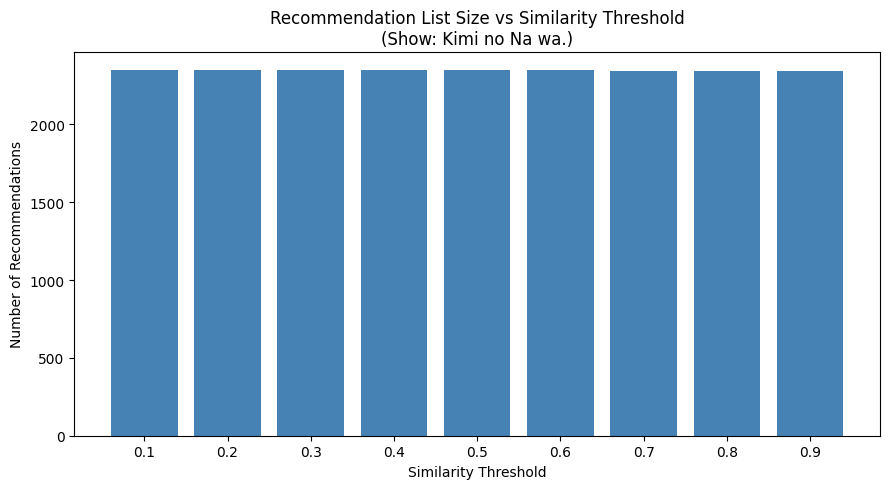

In [17]:
# Summary table – how list size changes with threshold
import matplotlib
import matplotlib.pyplot as plt

TEST_SHOW = "Kimi no Na wa."
index = np.where(TEST_SHOW == df1.index)[0][0]
scores = movies_cosine_sim[index]

thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
counts = []

for t in thresholds:
    n = sum(1 for i, s in enumerate(scores) if s >= t and i != index)
    counts.append(n)
    print(f"Threshold {t:.2f}  ->  {n:>4} recommendations")

# Bar chart
plt.figure(figsize=(9, 5))
plt.bar([str(t) for t in thresholds], counts, color='steelblue')
plt.title(f'Recommendation List Size vs Similarity Threshold\n(Show: {TEST_SHOW})')
plt.xlabel('Similarity Threshold')
plt.ylabel('Number of Recommendations')
plt.tight_layout()
plt.show()

In [18]:
# Test the same thresholds on a second anime to confirm the pattern holds
TEST_SHOW_2 = "Naruto"

for threshold in [0.90, 0.75, 0.50, 0.30, 0.10]:
    recommend_with_threshold(df1, TEST_SHOW_2, movies_cosine_sim, threshold=threshold)


Threshold = 0.9  →  3811 recommendation(s) for [Naruto]
----------------------------------------------------------------------
   1. .hack//Roots                                   score: 1.0000
   2. .hack//Sign                                    score: 1.0000
   3. .hack//Tasogare no Udewa Densetsu              score: 1.0000
   4. 0-sen Hayato                                   score: 1.0000
   5. 009-1                                          score: 1.0000
   6. 07-Ghost                                       score: 1.0000
   7. 11eyes                                         score: 1.0000
   8. 12-sai.: Chicchana Mune no Tokimeki            score: 1.0000
   9. 12-sai.: Chicchana Mune no Tokimeki 2nd Season  score: 1.0000
  10. 2020 Nyeon Ujuui Wonder Kiddy                  score: 1.0000
  11. 21 Emon                                        score: 1.0000
  12. 3 Choume no Tama: Uchi no Tama Shirimasenka?   score: 1.0000
  13. 3-Nen D-Gumi Glass no Kamen                    score: 1.0000


### Threshold Experiment – Observations

| Threshold | Effect |
|-----------|--------|
| **0.90 – 1.00** | Very strict – only near-identical anime recommended; list is very small |
| **0.70 – 0.89** | Strict – strong similarity required; moderate list size |
| **0.50 – 0.69** | Balanced – good mix of relevance and variety |
| **0.30 – 0.49** | Loose – broader recommendations; risk of less relevant results |
| **< 0.30**      | Very loose – large list but many weakly related titles |

**Key insight:** There is a clear trade-off between **precision** (how relevant each recommendation is) and **recall** (how many recommendations are returned). A threshold around **0.50–0.70** generally provides the best balance for this dataset.

In [19]:
'''
1) Difference between user-based and item-based collaborative filtering

- User-Based Collaborative Filtering:
  Similar users are grouped based on shared item preferences (ratings/reviews).
  The data matrix has users as rows and items as columns; cells hold ratings.
  Recommendations are made by finding users similar to the target user and
  suggesting items they liked that the target user hasn't seen.

- Item-Based Collaborative Filtering:
  Items with similar attributes/ratings are grouped together.
  The data matrix has items as rows and users as columns.
  Recommendations are made by finding items similar to ones the user already likes.

2) Collaborative Filtering (general):
  A recommendation technique that suggests items based on user behaviour patterns,
  not item content alone. It finds similar users or items using past interactions
  (ratings, clicks, purchases). Improves automatically as more interaction data
  becomes available. Two main types: user-based and item-based.
'''

"\n1) Difference between user-based and item-based collaborative filtering\n\n- User-Based Collaborative Filtering:\n  Similar users are grouped based on shared item preferences (ratings/reviews).\n  The data matrix has users as rows and items as columns; cells hold ratings.\n  Recommendations are made by finding users similar to the target user and\n  suggesting items they liked that the target user hasn't seen.\n\n- Item-Based Collaborative Filtering:\n  Items with similar attributes/ratings are grouped together.\n  The data matrix has items as rows and users as columns.\n  Recommendations are made by finding items similar to ones the user already likes.\n\n2) Collaborative Filtering (general):\n  A recommendation technique that suggests items based on user behaviour patterns,\n  not item content alone. It finds similar users or items using past interactions\n  (ratings, clicks, purchases). Improves automatically as more interaction data\n  becomes available. Two main types: user-bas